In [14]:
# 1 超前
import control as ct
import numpy as np
import matplotlib.pyplot as plt

# 定义原始系统的开环传递函数 G(s)
# G(s) = 1 / (s^2 + 2s)
num_g = [1,2]
den_g = [1, 1, 0]
G = ct.tf(num_g, den_g)

print("原始系统 G(s):")
print(G)

原始系统 G(s):

 s + 2
-------
s^2 + s



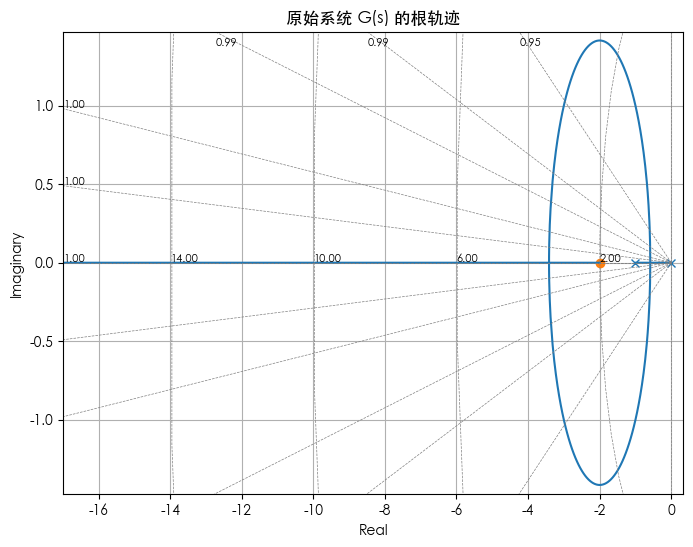

In [15]:
# 绘制原始系统的根轨迹
import matplotlib.pyplot as plt

# Set the font to a Chinese-friendly one
plt.rcParams['font.family'] = 'STHeiti' # Or the name of the font you added
plt.rcParams['axes.unicode_minus'] = False # This is to make sure the minus sign displays correctly
plt.figure(figsize=(8, 6))
ct.root_locus(G, plot=True)
plt.title("原始系统 G(s) 的根轨迹")
plt.grid(True)
plt.show()


超前补偿器 H(s):

s + 6
------
s + 10



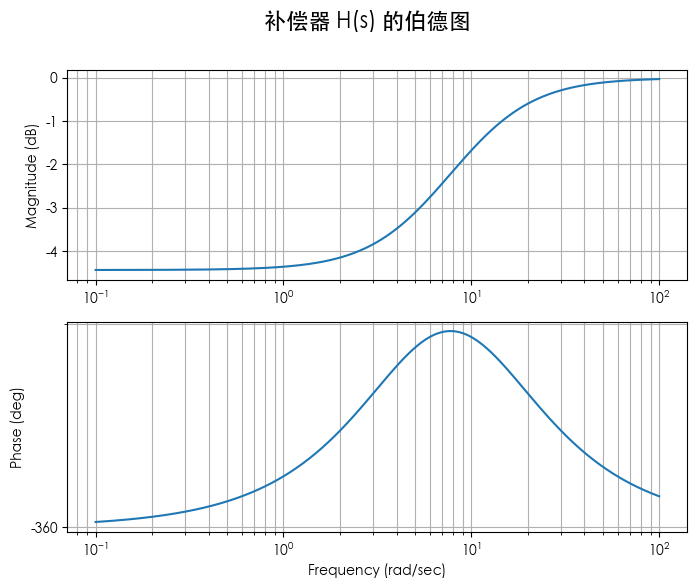

In [11]:
# 定义超前补偿器 H(s) = (s+6)/(s+10)
num_h = [1, 6]
den_h = [1, 10]
H = ct.tf(num_h, den_h)

print("\n超前补偿器 H(s):")
print(H)

# 绘制补偿器 H(s) 的伯德图
plt.figure(figsize=(8, 6))
ct.bode_plot(H, plot=True, dB=True, Hz=False, omega_limits=(0.1, 100))
plt.suptitle("补偿器 H(s) 的伯德图", fontsize=16)
plt.show()


补偿后的系统 Gc(s):

       s + 6
-------------------
s^3 + 12 s^2 + 20 s



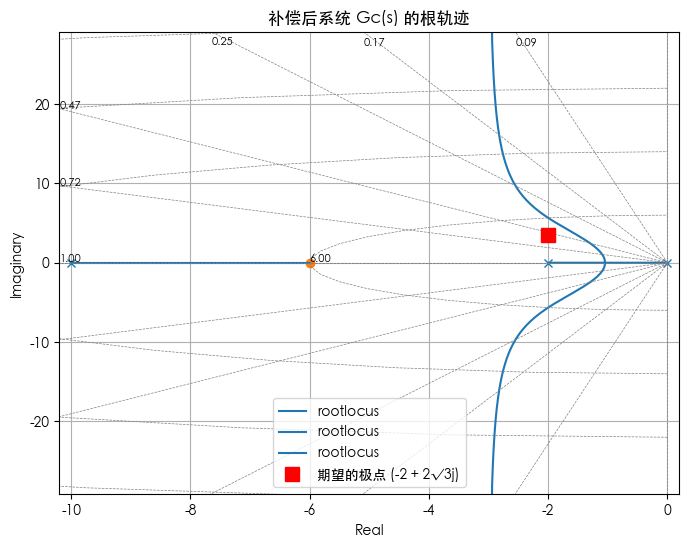

In [10]:
# 计算补偿后的系统 Gc(s) = G(s) * H(s)
Gc = ct.series(G, H)

print("\n补偿后的系统 Gc(s):")
print(Gc)

# 绘制补偿后系统的根轨迹
plt.figure(figsize=(8, 6))
ct.root_locus(Gc, plot=True)

# 标记期望的闭环极点位置
desired_pole = -2 + 2 * np.sqrt(3) * 1j
plt.plot(np.real(desired_pole), np.imag(desired_pole), 'rs', markersize=10, label='期望的极点 (-2 + 2√3j)')
plt.title("补偿后系统 Gc(s) 的根轨迹")
plt.legend()
plt.grid(True)
plt.show()

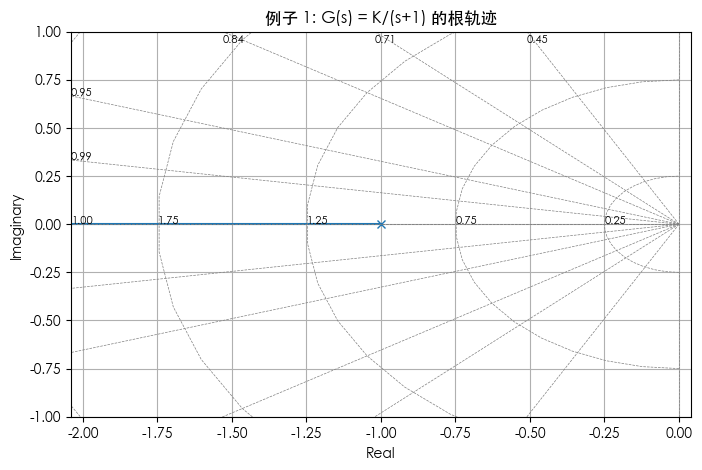

In [12]:
import control as ct
import matplotlib.pyplot as plt

# 定义系统 G(s) = 1/(s+1)
G1 = ct.tf([1], [1, 1])

plt.figure(figsize=(8, 5))
ct.root_locus(G1, plot=True)
plt.title("例子 1: G(s) = K/(s+1) 的根轨迹")
plt.grid(True)
plt.show()

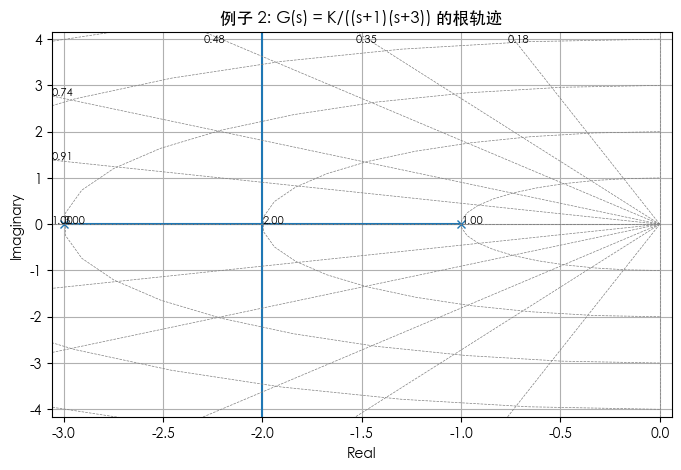

In [13]:
import control as ct
import matplotlib.pyplot as plt
import numpy as np

# 定义系统 G(s) = 1/((s+1)(s+3))
G2 = ct.tf([1], np.poly([-1, -3])) # 使用poly从根创建多项式

plt.figure(figsize=(8, 5))
ct.root_locus(G2, plot=True)
plt.title("例子 2: G(s) = K/((s+1)(s+3)) 的根轨迹")
plt.grid(True)
plt.show()

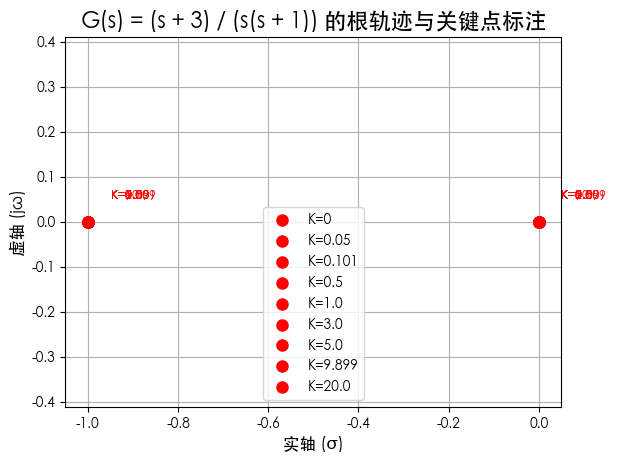

In [21]:
import control as ct
import matplotlib.pyplot as plt
import numpy as np

# 1. 定义开环传递函数 G(s) = (s + 3) / (s^2 + s)
s = ct.tf('s')
G = (s + 3) / (s * (s + 1))

K_values = [0, 0.05, 0.101, 0.5, 1.0, 3.0, 5.0, 9.899, 20.0]

# plt.figure(figsize=(12, 8))
# rlist, klist = ct.root_locus(G, plot=True)

for K in K_values:
    poles = ct.pole(G * K)
    plt.plot(np.real(poles), np.imag(poles), 'o', label=f'K={K}')
    real_parts = np.real(poles)
    imag_parts = np.imag(poles)
    
    # 在图上用红色的圆点 'o' 标注出这些极点
    plt.plot(real_parts, imag_parts, 'ro', markersize=8, label=f'K={K}' if K in K_values else "")

    # 在每个点的旁边添加文本标签，显示K值
    # 为了避免标签与点重叠，我们给文本位置一个微小的偏移
    for i in range(len(poles)):
        plt.text(real_parts[i] + 0.05, imag_parts[i] + 0.05, f'K={K}', fontsize=9, color='red')


plt.title('G(s) = (s + 3) / (s(s + 1)) 的根轨迹与关键点标注', fontsize=16)
plt.xlabel('实轴 (σ)', fontsize=12)
plt.ylabel('虚轴 (jω)', fontsize=12)
plt.grid(True)

# !!! 关键步骤：设置坐标轴比例相等，这样圆看起来才是圆，而不是椭圆
# plt.axis('equal') 

# 调整图例，避免重复标签
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys()) # 如果需要图例可以取消这行注释

plt.show()

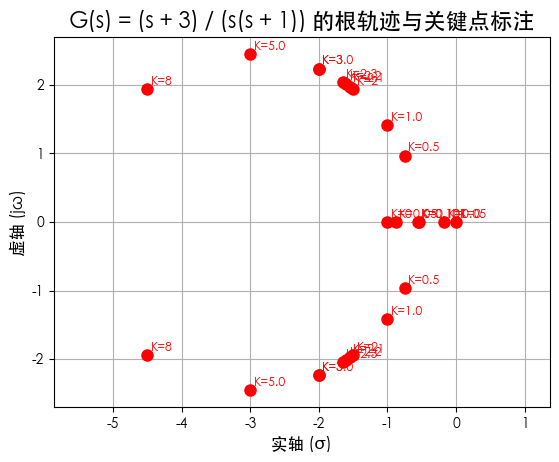

In [30]:
import control as ct
import matplotlib.pyplot as plt
import numpy as np

# 1. 定义开环传递函数 G(s) = (s + 3) / (s^2 + s)
s = ct.tf('s')
G = (s + 3) / (s * (s + 1))

# 2. 定义我们想要特别标注的K值
# 这些值来自我们之前的分析表格
K_values = [0, 0.05, 0.101, 0.5, 1.0, 3.0, 5.0, 3,2,2.1,2.2,2.3,8]

# 3. 绘制基础的根轨迹图
# plot=True 会自动生成一个图
# plt.figure(figsize=(12, 8))
# rlist, klist = ct.root_locus(G, plot=True)

# 4. 计算并标注我们指定的K值对应的闭环极点
for K in K_values:
    # 闭环特征方程: s^2 + (1+K)s + 3K = 0
    # 使用numpy的roots函数求解方程的根（即闭环极点）
    poles = np.roots([1, 1 + K, 3 * K])
    
    # 提取极点的实部和虚部
    real_parts = np.real(poles)
    imag_parts = np.imag(poles)
    
    # 在图上用红色的圆点 'o' 标注出这些极点
    plt.plot(real_parts, imag_parts, 'ro', markersize=8, label=f'K={K}' if K in K_values else "")

    # 在每个点的旁边添加文本标签，显示K值
    # 为了避免标签与点重叠，我们给文本位置一个微小的偏移
    for i in range(len(poles)):
        plt.text(real_parts[i] + 0.05, imag_parts[i] + 0.05, f'K={K}', fontsize=9, color='red')

# 5. 美化和设置图形
plt.title('G(s) = (s + 3) / (s(s + 1)) 的根轨迹与关键点标注', fontsize=16)
plt.xlabel('实轴 (σ)', fontsize=12)
plt.ylabel('虚轴 (jω)', fontsize=12)
plt.grid(True)

# !!! 关键步骤：设置坐标轴比例相等，这样圆看起来才是圆，而不是椭圆
plt.axis('equal') 

# 调整图例，避免重复标签
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
# plt.legend(by_label.values(), by_label.keys()) # 如果需要图例可以取消这行注释

plt.show()